# SA2. Clasificacion - diabetes.csv

Prediccion de `Outcome` (diabetes si/no) usando un **Arbol de Decision**, elegido por ser interpretable (permite visualizar las reglas de decision completas) y no requerir escalado de variables.

## 1. Carga de datos y tratamiento de valores faltantes

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, joblib, os

df = pd.read_csv('diabetes.csv')
print(df.shape)
df.head()


(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
# Glucose, BloodPressure, SkinThickness, Insulin y BMI en 0 son biologicamente imposibles
# -> se tratan como nulos y se imputan con la mediana de cada columna
cols_cero_invalido = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for c in cols_cero_invalido:
    n_ceros = (df[c] == 0).sum()
    print(f'{c}: {n_ceros} valores en 0')
    df[c] = df[c].replace(0, np.nan)
    df[c] = df[c].fillna(df[c].median())
df.describe().T[['min','max','mean']]


Glucose: 5 valores en 0
BloodPressure: 35 valores en 0
SkinThickness: 227 valores en 0
Insulin: 374 valores en 0
BMI: 11 valores en 0


,min,max,mean
Pregnancies,0.000,17.00,3.845052
Glucose,44.000,199.00,121.656250
BloodPressure,24.000,122.00,72.386719
SkinThickness,7.000,99.00,29.108073
Insulin,14.000,846.00,140.671875
BMI,18.200,67.10,32.455208
DiabetesPedigreeFunction,0.078,2.42,0.471876
Age,21.000,81.00,33.240885
Outcome,0.000,1.00,0.348958


## 2. Analisis de correlacion con Outcome

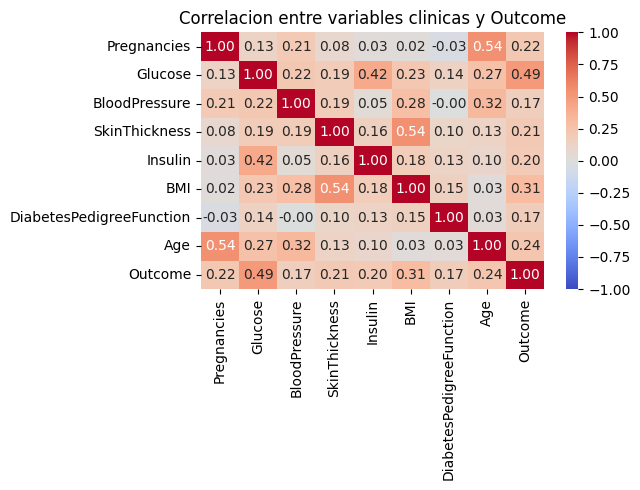

Outcome                     1.000000
Glucose                     0.492782
BMI                         0.312038
Age                         0.238356
Pregnancies                 0.221898
SkinThickness               0.214873
Insulin                     0.203790
DiabetesPedigreeFunction    0.173844
BloodPressure               0.165723
Name: Outcome, dtype: float64


In [3]:
plt.figure(figsize=(6.5, 5))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlacion entre variables clinicas y Outcome')
plt.tight_layout()
plt.show()
print(corr['Outcome'].sort_values(ascending=False))


## 3. Division train/test estratificada (80/20)

In [4]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Outcome'])
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train.shape, X_test.shape


((614, 8), (154, 8))

## 4. Modelo base (sin optimizar) - referencia de sobreajuste

In [5]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

base_model = DecisionTreeClassifier(random_state=42)
base_model.fit(X_train, y_train)
acc_base = accuracy_score(y_test, base_model.predict(X_test))
print('Profundidad del arbol base:', base_model.get_depth())
print('Accuracy modelo base (sobreajustado):', round(acc_base, 3))


Profundidad del arbol base: 14
Accuracy modelo base (sobreajustado): 0.682


## 5. Busqueda de hiperparametros (GridSearchCV, CV 5-fold)

In [6]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 4, 5, 6, 7, 8, 10, 12],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 5, 10, 15]
}

grid = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)

print('Mejores hiperparametros:', grid.best_params_)
print('F1 promedio (CV 5-fold):', round(grid.best_score_, 3))


Mejores hiperparametros: {'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 10, 'min_samples_split': 2}
F1 promedio (CV 5-fold): 0.641


## 6. Modelo final y evaluacion

In [7]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print('Accuracy optimizado:', round(acc, 3))
print('Precision:', round(prec, 3))
print('Recall:', round(rec, 3))
print('F1-score:', round(f1, 3))
print('ROC-AUC:', round(auc, 3))


Accuracy optimizado: 0.779
Precision: 0.75
Recall: 0.556
F1-score: 0.638
ROC-AUC: 0.836


## 7. Matriz de confusion

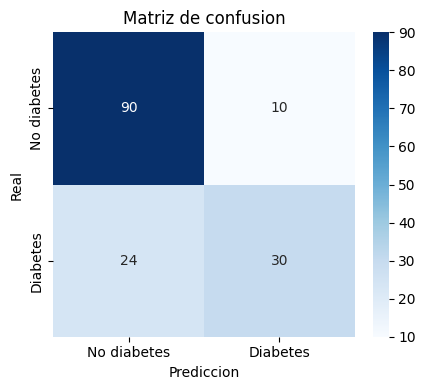

In [8]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No diabetes', 'Diabetes'], yticklabels=['No diabetes', 'Diabetes'])
plt.xlabel('Prediccion'); plt.ylabel('Real')
plt.title('Matriz de confusion')
plt.tight_layout()
plt.show()


## 8. Curva ROC

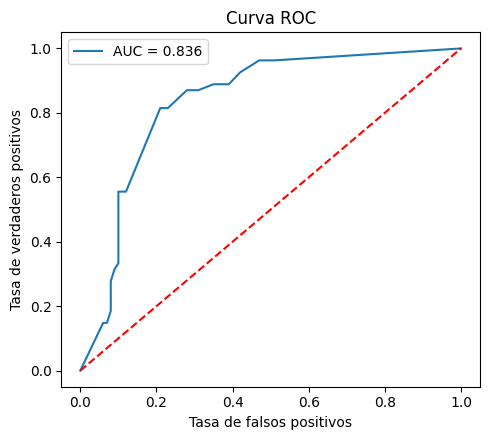

In [9]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(5, 4.5))
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('Tasa de falsos positivos'); plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curva ROC')
plt.legend()
plt.tight_layout()
plt.show()


## 9. Importancia de variables

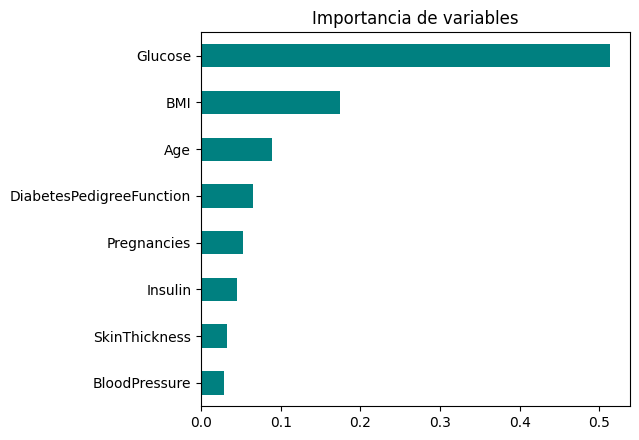

In [10]:
importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values()
plt.figure(figsize=(6.5, 4.5))
importances.plot(kind='barh', color='teal')
plt.title('Importancia de variables')
plt.tight_layout()
plt.show()


## 10. Visualizacion del arbol de decision completo

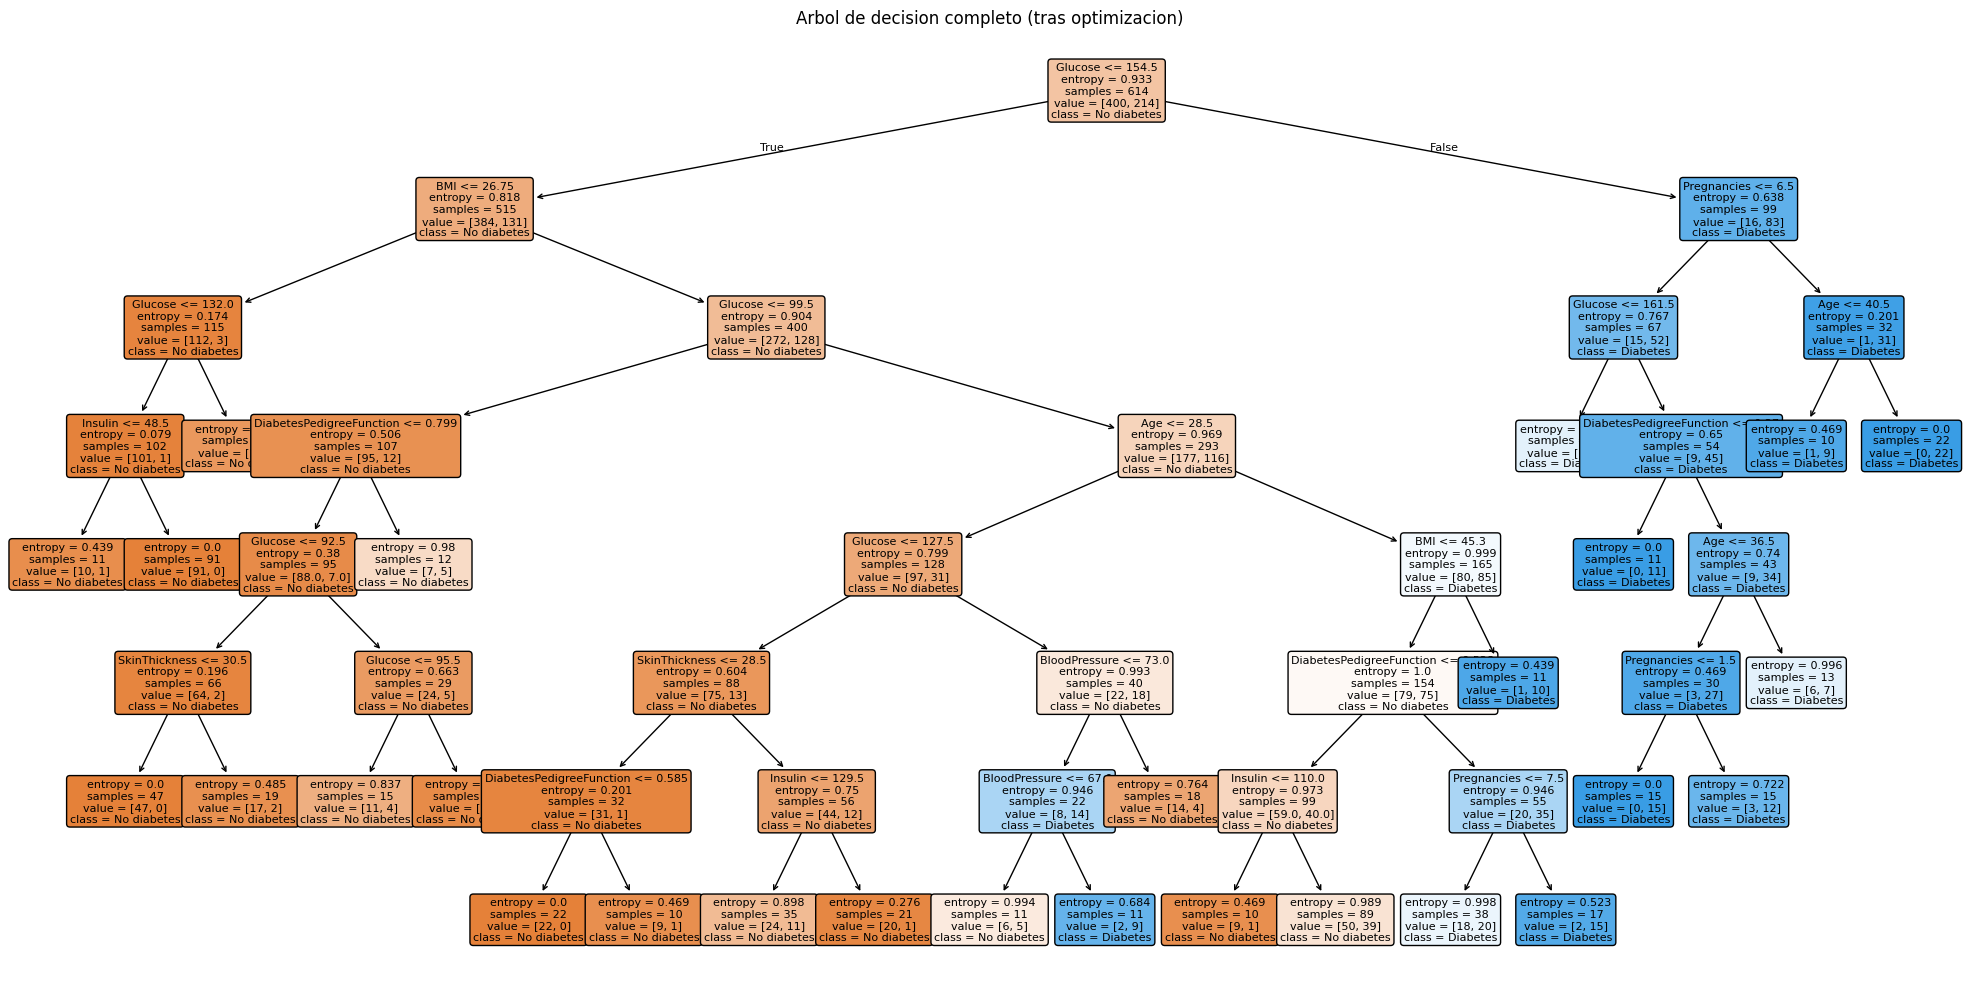

In [11]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(best_model, feature_names=X.columns, class_names=['No diabetes','Diabetes'],
          filled=True, rounded=True, fontsize=8)
plt.title('Arbol de decision completo (tras optimizacion)')
plt.tight_layout()
plt.show()


## 11. Guardado del modelo y de las metricas

In [12]:
os.makedirs('modelo', exist_ok=True)
joblib.dump(best_model, 'modelo/modelo_clasificacion_diabetes.pkl')

metrics = {
    "algoritmo": "Arbol de Decision (DecisionTreeClassifier)",
    "dataset": "diabetes.csv",
    "mejores_hiperparametros": grid.best_params_,
    "metricas": {
        "accuracy_modelo_base": round(float(acc_base), 3),
        "accuracy_modelo_optimizado": round(float(acc), 3),
        "precision": round(float(prec), 3),
        "recall": round(float(rec), 3),
        "f1_score": round(float(f1), 3),
        "roc_auc": round(float(auc), 3),
        "f1_promedio_cv_5fold": round(float(grid.best_score_), 3)
    }
}
print(json.dumps(metrics, indent=2, ensure_ascii=False))
print('\nModelo guardado en modelo/modelo_clasificacion_diabetes.pkl')


{
  "algoritmo": "Arbol de Decision (DecisionTreeClassifier)",
  "dataset": "diabetes.csv",
  "mejores_hiperparametros": {
    "criterion": "entropy",
    "max_depth": 7,
    "min_samples_leaf": 10,
    "min_samples_split": 2
  },
  "metricas": {
    "accuracy_modelo_base": 0.682,
    "accuracy_modelo_optimizado": 0.779,
    "precision": 0.75,
    "recall": 0.556,
    "f1_score": 0.638,
    "roc_auc": 0.836,
    "f1_promedio_cv_5fold": 0.641
  }
}

Modelo guardado en modelo/modelo_clasificacion_diabetes.pkl
